# NY Vir Newtonian N-Body Modeling
Demonstrates Newtonian N-body modeling using Rebound.

In [ ]:
%load_ext autoreload
%autoreload 2
import os
os.environ['PYTENSOR_FLAGS'] = 'mode=NUMBA'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from ocpy.data import Data

data = Data.from_file("../ny_vir_minima.xlsx")
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2453174.442769
period = 0.1010159690

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="lmfit"
)

In [ ]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter

nbody = NewtonianModel(
    central_mass=Parameter(value=0.611, fixed=True),
    T0_ref=t0,
    P_ref=period,
    bodies = [
        {
            "m":     Parameter(value=0.0021, fixed=False, std=1,  min=0),
            "P":     Parameter(value=3170.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.05,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=269.0,  fixed=False, std=200, min=0, max=360), # [0, 360] arası
            "T":     Parameter(value=2443302.0, fixed=False, std=3170.0), # std ~ P
        },
        {
            "m":     Parameter(value=0.0038, fixed=False, std=1,  min=0),
            "P":     Parameter(value=8260.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.02,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=140.0,  fixed=False, std=200, min=0, max=360), # [0, 360] arası
            "T":     Parameter(value=2421163.0, fixed=False, std=8260.0), # std ~ P
        }
    ],
    name="nbody"
)
models = [nbody]

In [ ]:
res = oc.fit(models)

res


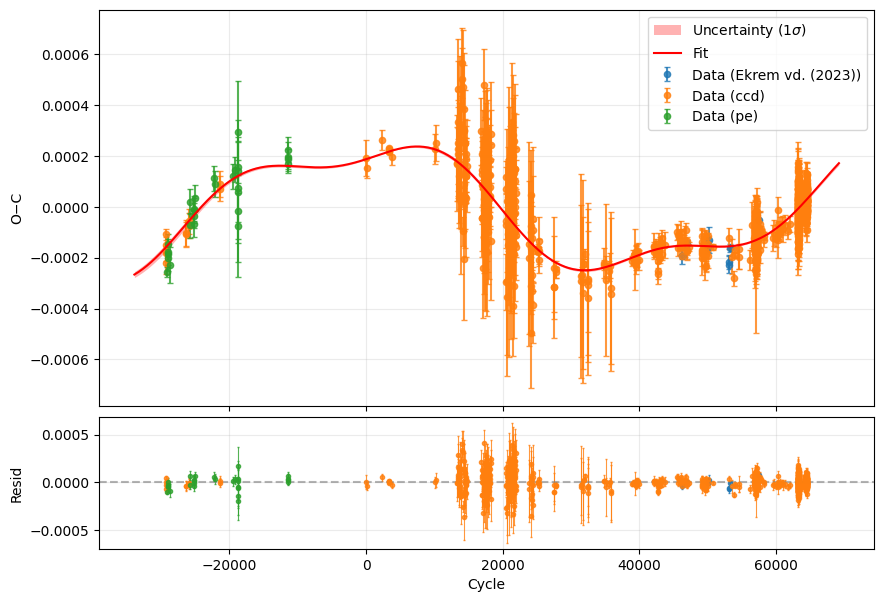

In [ ]:
oc.plot(res)
print("res")